# Imports

In [1]:
# Instalar PyTorch con CUDA (primero, para evitar que sentence-transformers instale CPU)
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


# Dataset and Preprocessing

In [2]:
import gc
import pandas as pd

from datasets import load_dataset
from datasets import Dataset

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("wangrongsheng/ag_news")
df_text_train = pd.DataFrame(dataset["train"])
df_text_test = pd.DataFrame(dataset["test"])

In [4]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
MAX_MODEL_LENGTH = 2048
MAX_LENGTH = 2048

In [5]:
label_token_dict = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science"
}

def build_prompt(review):

    prompt = f"""Article: {review}

Theme:"""

    return prompt


def build_full_text(review, label):

    theme = label_token_dict[label]

    full_text = f"""Article: {review}

Theme: {theme}"""

    return full_text


def preprocess_dataset(dataset, tokenizer):
    records = dataset.to_dict("records")

    reviews   = [r["text"]  for r in records]
    raw_labels = [r["label"] for r in records]

    full_texts   = [build_full_text(rev, lbl) for rev, lbl in zip(reviews, raw_labels)]
    prompt_texts = [build_prompt(rev) for rev in reviews]

    # tokenizacion en batch: 1 llamada en vez de N
    full_enc = tokenizer(
        full_texts,
        add_special_tokens=False,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
    )
    prompt_enc = tokenizer(
        prompt_texts,
        add_special_tokens=False,
    )

    labels_list = [
        [
            -100 if (i < len(prompt_ids) or attn == 0) else tok
            for i, (tok, attn) in enumerate(zip(input_ids, attention_mask))
        ]
        for input_ids, attention_mask, prompt_ids in zip(
            full_enc["input_ids"],
            full_enc["attention_mask"],
            prompt_enc["input_ids"],
        )
    ]

    true_labels_list = [label_token_dict[l] for l in raw_labels]

    return Dataset.from_dict({
        "input_ids":      full_enc["input_ids"],
        "attention_mask": full_enc["attention_mask"],
        "labels":         labels_list,
        "true_label":     true_labels_list,
    })

In [6]:
# Model tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [7]:
def fits_model(example):

    text = build_full_text(
        example["text"],
        example["label"]
    )

    tokens = tokenizer(
        text,
        add_special_tokens=False
    )["input_ids"]

    return len(tokens) <= MAX_MODEL_LENGTH

In [8]:
train_mask = df_text_train.groupby("label").cumcount() < 7500
df_masked_train = df_text_train[train_mask]
df_masked_train["label"].value_counts()

label
2    7500
3    7500
1    7500
0    7500
Name: count, dtype: int64

In [9]:
cumcount = df_text_train.groupby("label").cumcount()
val_mask = (cumcount >= 7500) & (cumcount < 7525)
df_masked_val = df_text_train[val_mask]
df_masked_val["label"].value_counts()

label
0    25
3    25
1    25
2    25
Name: count, dtype: int64

In [10]:
train_raw = df_masked_train
val_raw = df_masked_val
test_raw = df_text_test

In [11]:
# Reviews exceeding model context are removed from the dataset.
filtered_train = train_raw[train_raw.apply(fits_model, axis=1)]

filtered_val = val_raw[val_raw.apply(fits_model, axis=1)]

filtered_test = test_raw[test_raw.apply(fits_model, axis=1)]

In [12]:
train_dataset = preprocess_dataset(filtered_train, tokenizer)
val_dataset = preprocess_dataset(filtered_val, tokenizer)
test_dataset = preprocess_dataset(filtered_test, tokenizer)

In [13]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

val_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
        "true_label"
    ]
)

# Student definition

In [14]:
# LLM Model download
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3126.10it/s]


In [15]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [16]:
teacher_model.load_state_dict(
      torch.load(
          "../checkpoints/agnews/best_teacher_model.pt",
          map_location=device
      )
  )

<All keys matched successfully>

In [17]:
teacher_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [18]:
from transformers import AutoConfig

# cargar config del teacher
config = AutoConfig.from_pretrained(MODEL_NAME)

# reducir capas si querés student 11 capas
config.num_hidden_layers = 11

# crear student RANDOM
student_model = AutoModelForCausalLM.from_config(config)

In [19]:
student_model.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-10): 11 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

# Student training

In [20]:
def collate_fn(batch):
    input_ids      = [b["input_ids"].clone()      for b in batch]
    attention_mask = [b["attention_mask"].clone()  for b in batch]
    labels         = [b["labels"].clone()          for b in batch]
    true_labels    = [b["true_label"]              for b in batch]

    return {
        "input_ids":      torch.nn.utils.rnn.pad_sequence(input_ids,      batch_first=True, padding_value=tokenizer.pad_token_id),
        "attention_mask": torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0),
        "labels":         torch.nn.utils.rnn.pad_sequence(labels,         batch_first=True, padding_value=-100),
        "true_label":     true_labels,
    }

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [21]:
def save_checkpoint(model, optimizer, epoch, global_step, path="checkpoint.pt"):

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "global_step": global_step
        },
        path
    )

def load_checkpoint(model, optimizer, path="checkpoint.pt"):

    ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    return ckpt["epoch"], ckpt["global_step"]

In [22]:
# =========================
# CONFIG DISTILLATION
# =========================
temperature = 2.0
alpha = 0.5
lr = 1e-4

EPOCHS = 3

teacher_model.eval()
student_model.train()

for p in teacher_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=lr
)

In [23]:
best_val_loss = float("inf")
eval_every = 1000
save_every = 2000
start_epoch = 0
global_step = 0
max_val_steps = 100

In [24]:
try:
    start_epoch, global_step = load_checkpoint(
        student_model,
        optimizer,
        "../checkpoints/agnews/student_checkpoint.pt"
    )

    print(f"[RESUME] Epoch {start_epoch} | Global step {global_step}")

except:
    print("[START] Training from scratch")


# =========================
# INIT LOSS
# =========================

student_model.eval()

with torch.no_grad():
    batch = next(iter(train_loader))

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    n_tokens = attention_mask.float().sum()

    teacher_outputs = teacher_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    student_outputs = student_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    ce_loss = student_outputs.loss

    kd_loss = F.kl_div(
        F.log_softmax(
            student_outputs.logits / temperature,
            dim=-1
        ),
        F.softmax(
            teacher_outputs.logits / temperature,
            dim=-1
        ),
        reduction="batchmean"
    ) * (temperature ** 2) / n_tokens

    init_loss = (
        alpha * ce_loss
        + (1 - alpha) * kd_loss
    )

    print(
        f"[INIT LOSS] "
        f"Total={init_loss.item():.4f} | "
        f"CE={ce_loss.item():.4f} | "
        f"KD={kd_loss.item():.4f}"
    )

student_model.train()

# =========================
# TRAINING
# =========================

for epoch in range(start_epoch, EPOCHS):

    student_model.train()

    total_loss = 0
    total_ce = 0
    total_kd = 0

    for step, batch in enumerate(train_loader):

        global_step += 1

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        n_tokens = attention_mask.float().sum()

        # =========================
        # TEACHER
        # =========================

        with torch.no_grad():

            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # =========================
        # student
        # =========================

        student_outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        ce_loss = student_outputs.loss

        kd_loss = F.kl_div(
            F.log_softmax(
                student_outputs.logits / temperature,
                dim=-1
            ),
            F.softmax(
                teacher_outputs.logits / temperature,
                dim=-1
            ),
            reduction="batchmean"
        ) * (temperature ** 2) / n_tokens

        loss = (
            alpha * ce_loss
            + (1 - alpha) * kd_loss
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_kd += kd_loss.item()

        if global_step % 50 == 0:

            avg_loss = total_loss / (step + 1)
            avg_ce = total_ce / (step + 1)
            avg_kd = total_kd / (step + 1)

            print(
                f"Epoch {epoch} | "
                f"Step {step} | "
                f"Global {global_step} | "
                f"Loss {avg_loss:.4f} | "
                f"CE {avg_ce:.4f} | "
                f"KD {avg_kd:.4f}"
            )

        # =========================
        # VALIDATION
        # =========================

        if global_step % eval_every == 0:

            student_model.eval()

            val_loss = 0
            val_steps = 0

            with torch.no_grad():

                for val_batch in val_loader:

                    val_steps += 1

                    input_ids = (
                        val_batch["input_ids"]
                        .to(device)
                    )

                    attention_mask = (
                        val_batch["attention_mask"]
                        .to(device)
                    )

                    labels = (
                        val_batch["labels"]
                        .to(device)
                    )

                    n_tokens = attention_mask.float().sum()

                    teacher_outputs = teacher_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )

                    student_outputs = student_model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )

                    ce_loss = student_outputs.loss

                    kd_loss = F.kl_div(
                        F.log_softmax(
                            student_outputs.logits
                            / temperature,
                            dim=-1
                        ),
                        F.softmax(
                            teacher_outputs.logits
                            / temperature,
                            dim=-1
                        ),
                        reduction="batchmean"
                    ) * (temperature ** 2) / n_tokens

                    batch_loss = (
                        alpha * ce_loss
                        + (1 - alpha) * kd_loss
                    )

                    val_loss += batch_loss.item()

                    if val_steps >= max_val_steps:
                        break

            val_loss /= val_steps

            print(
                f"\n[VAL LOSS] "
                f"{val_loss:.4f}\n"
            )

            # =========================
            # BEST MODEL
            # =========================

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                patience_counter = 0

                torch.save(
                    student_model.state_dict(),
                    "../checkpoints/agnews/best_student_model.pt"
                )

                print("[BEST MODEL SAVED]")

            else:
                patience_counter += 1

            # =========================
            # CHECKPOINT
            # =========================

            save_checkpoint(
                student_model,
                optimizer,
                epoch,
                global_step,
                "../checkpoints/agnews/student_checkpoint.pt"
            )


        # =========================
        # CLEANUP
        # =========================

        del (
            input_ids,
            attention_mask,
            labels,
            teacher_outputs,
            student_outputs,
            ce_loss,
            kd_loss,
            loss
        )

    gc.collect()

[START] Training from scratch
[INIT LOSS] Total=79.0596 | CE=10.2272 | KD=147.8919
Epoch 0 | Step 49 | Global 50 | Loss 39.2399 | CE 8.1007 | KD 70.3791
Epoch 0 | Step 99 | Global 100 | Loss 29.6071 | CE 4.9936 | KD 54.2207
Epoch 0 | Step 149 | Global 150 | Loss 25.1508 | CE 3.9267 | KD 46.3749
Epoch 0 | Step 199 | Global 200 | Loss 22.3683 | CE 3.3568 | KD 41.3799
Epoch 0 | Step 249 | Global 250 | Loss 20.5549 | CE 3.0621 | KD 38.0477
Epoch 0 | Step 299 | Global 300 | Loss 19.2901 | CE 2.8275 | KD 35.7528
Epoch 0 | Step 349 | Global 350 | Loss 18.3179 | CE 2.6567 | KD 33.9792
Epoch 0 | Step 399 | Global 400 | Loss 17.7878 | CE 2.5549 | KD 33.0207
Epoch 0 | Step 449 | Global 450 | Loss 17.2767 | CE 2.4575 | KD 32.0959
Epoch 0 | Step 499 | Global 500 | Loss 16.7886 | CE 2.3598 | KD 31.2173
Epoch 0 | Step 549 | Global 550 | Loss 16.3620 | CE 2.2736 | KD 30.4505
Epoch 0 | Step 599 | Global 600 | Loss 15.9754 | CE 2.2003 | KD 29.7505
Epoch 0 | Step 649 | Global 650 | Loss 15.7721 | CE 2.13

In [25]:
student_model.load_state_dict(
    torch.load(
        "../checkpoints/agnews/best_student_model.pt",
        map_location=device
    )
)

<All keys matched successfully>

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =========================
# TARGET TOKENS
# =========================

CLASS_LABELS = ["World", "Sports", "Business", "Science"]

class_token_ids = [
    tokenizer.encode(f" {label}", add_special_tokens=False)[0]
    for label in CLASS_LABELS
]

# =========================
# TEST EVALUATION
# =========================

student_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        true_labels = batch["true_label"]

        outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_idx = attention_mask.sum(dim=1) - 2

        logits = outputs.logits[
            torch.arange(input_ids.size(0), device=device),
            last_idx
        ]

        class_logits = logits[:, class_token_ids]
        pred_indices = class_logits.argmax(dim=-1)

        for pred_idx, t in zip(pred_indices, true_labels):
            y_pred.append(CLASS_LABELS[pred_idx.item()])
            y_true.append(t)

student_model.cpu()

# =========================
# METRICS
# =========================

test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0,
    labels=CLASS_LABELS
)

test_recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0,
    labels=CLASS_LABELS
)

test_f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0,
    labels=CLASS_LABELS
)

cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)

In [27]:
# =========================
# PRINT
# =========================

print("\n=========================")
print("[TEST RESULTS]")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print("=========================\n")

print("[CONFUSION MATRIX]")
print(cm)


[TEST RESULTS]
Accuracy : 0.8784
Precision: 0.8784
Recall   : 0.8784
F1 Score : 0.8784

[CONFUSION MATRIX]
[[1696   41  107   56]
 [  42 1798   40   20]
 [  81   27 1570  222]
 [  83   34  171 1612]]


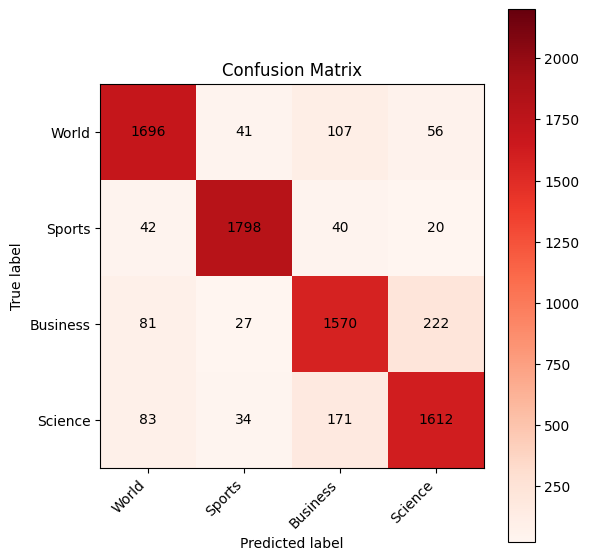

In [28]:
import matplotlib.pyplot as plt

n = len(CLASS_LABELS)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(cm, cmap="Reds", vmax=2200)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_LABELS, rotation=45, ha="right")
ax.set_yticklabels(CLASS_LABELS)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

for i in range(n):
    for j in range(n):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()